<a href="https://colab.research.google.com/github/dhanushkumar2968/Car-colour-detection-Model/blob/main/nationality_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Nationality Detection Model

**What this project does:**
- Uploads a person's image and predicts their **Nationality**
- Predicts **Emotion** for everyone
- Extra predictions based on nationality:

| Nationality | Predictions |
|-------------|-------------|
| 🇮🇳 Indian   | Nationality + Age + Dress Colour + Emotion |
| 🇺🇸 American | Nationality + Age + Emotion |
| 🌍 African   | Nationality + Emotion + Dress Colour |
| 🌐 Others    | Nationality + Emotion only |

**No Kaggle dataset needed!** We use DeepFace — a pre-trained model that already knows faces.

---

### ✅ CELL 1 — Install All Required Libraries

In [1]:
# Install everything needed
!pip install deepface opencv-python-headless ipywidgets Pillow tf_keras --quiet

print("✅ All libraries installed!")
print("\n📦 What each library does:")
print("   deepface   → Detects age, emotion, race from face images")
print("   opencv     → Image processing (colours, drawing boxes)")
print("   ipywidgets → GUI buttons and layout")
print("   Pillow     → Open and display images")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.3 MB/s eta 0:00:00
✅ All libraries installed!

📦 What each library does:
   deepface   → Detects age, emotion, race from face images
   opencv     → Image processing (colours, drawing boxes)
   ipywidgets → GUI buttons and layout
   Pillow     → Open and display images


### ✅ CELL 2 — Import Libraries

In [2]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# DeepFace — the main model for face analysis
from deepface import DeepFace

print("✅ All imports successful!")

26-05-21 02:09:21 - Directory /root/.deepface has been created
26-05-21 02:09:21 - Directory /root/.deepface/weights has been created
✅ All imports successful!


### ✅ CELL 3 — Dress Colour Detection Function

In [3]:
# ─────────────────────────────────────────────────────────────
# FUNCTION: Detect the dominant dress/clothing colour
#
# How it works:
#   1. Take the bottom 60% of the image (where clothing usually is)
#   2. Use K-Means clustering to find the most common colour
#   3. Match that colour to a human-readable colour name
# ─────────────────────────────────────────────────────────────

def get_dress_colour(image_path):
    """
    Detects the dominant colour of the clothing in the image.
    Returns colour name (e.g. 'Red', 'Blue', 'White')
    """

    # Load image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]

    # Crop bottom 60% of image = clothing area
    clothing_region = img_rgb[int(h * 0.40):, :]

    # Reshape to a list of pixels
    pixels = clothing_region.reshape(-1, 3).astype(np.float32)

    # Use K-Means to find top 1 dominant colour
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 0.1)
    _, labels, centers = cv2.kmeans(pixels, 3, None, criteria, 10,
                                     cv2.KMEANS_RANDOM_CENTERS)

    # Find the most common cluster
    counts = np.bincount(labels.flatten())
    dominant_colour = centers[np.argmax(counts)].astype(int)
    r, g, b = dominant_colour[0], dominant_colour[1], dominant_colour[2]

    # ── Match RGB to colour name ──
    colour_map = [
        ('White',      (255, 255, 255)),
        ('Black',      (0,   0,   0  )),
        ('Red',        (255, 0,   0  )),
        ('Green',      (0,   128, 0  )),
        ('Blue',       (0,   0,   255)),
        ('Yellow',     (255, 255, 0  )),
        ('Orange',     (255, 165, 0  )),
        ('Purple',     (128, 0,   128)),
        ('Pink',       (255, 182, 193)),
        ('Brown',      (139, 69,  19 )),
        ('Gray',       (128, 128, 128)),
        ('Navy Blue',  (0,   0,   128)),
        ('Light Blue', (173, 216, 230)),
        ('Maroon',     (128, 0,   0  )),
        ('Beige',      (245, 245, 220)),
    ]

    # Find nearest colour by Euclidean distance
    min_dist = float('inf')
    colour_name = 'Unknown'
    for name, (cr, cg, cb) in colour_map:
        dist = ((r-cr)**2 + (g-cg)**2 + (b-cb)**2) ** 0.5
        if dist < min_dist:
            min_dist = dist
            colour_name = name

    # Also return the actual RGB for display
    return colour_name, (r, g, b), clothing_region

print("✅ Dress colour detection function ready!")

✅ Dress colour detection function ready!


### ✅ CELL 4 — Nationality Mapping Function

In [4]:
# ─────────────────────────────────────────────────────────────
# DeepFace returns these race labels:
#   'indian', 'asian', 'black', 'white', 'middle eastern',
#   'latino hispanic'
#
# We map them to readable nationalities
# ─────────────────────────────────────────────────────────────

NATIONALITY_MAP = {
    'indian':           'Indian',
    'asian':            'Asian',
    'black':            'African',
    'white':            'American',      # mapped to US for this project
    'middle eastern':   'Middle Eastern',
    'latino hispanic':  'Latino / Hispanic',
}

def map_nationality(deepface_race):
    """
    Converts DeepFace race label to readable nationality.
    Returns the nationality string.
    """
    race_lower = deepface_race.lower().strip()
    return NATIONALITY_MAP.get(race_lower, 'Other')


def get_nationality_flag(nationality):
    """Returns a flag emoji for the nationality."""
    flags = {
        'Indian':             '🇮🇳',
        'American':           '🇺🇸',
        'African':            '🌍',
        'Asian':              '🌏',
        'Middle Eastern':     '🕌',
        'Latino / Hispanic':  '🌎',
        'Other':              '🌐',
    }
    return flags.get(nationality, '🌐')


def get_emotion_emoji(emotion):
    """Returns an emoji for the emotion."""
    emojis = {
        'happy':    '😊',
        'sad':      '😢',
        'angry':    '😠',
        'fear':     '😨',
        'disgust':  '🤢',
        'surprise': '😲',
        'neutral':  '😐',
    }
    return emojis.get(emotion.lower(), '🙂')

print("✅ Nationality mapping functions ready!")

✅ Nationality mapping functions ready!


### ✅ CELL 5 — Main Analysis Function

In [5]:
# ─────────────────────────────────────────────────────────────
# MAIN FUNCTION: Analyses an image and returns all predictions
#
# Steps:
#   1. Run DeepFace → get age, emotion, race
#   2. Map race → nationality
#   3. Based on nationality → decide what extra info to show
#   4. Get dress colour if needed
#   5. Return a clean results dictionary
# ─────────────────────────────────────────────────────────────

def analyse_person(image_path):
    """
    Full analysis of a person's image.
    Returns a dictionary with all detected attributes.
    """

    results = {
        'success':      False,
        'nationality':  None,
        'emotion':      None,
        'age':          None,
        'dress_colour': None,
        'dress_rgb':    None,
        'show_age':     False,
        'show_dress':   False,
        'all_emotions': {},
        'error':        None
    }

    try:
        print("🔍 Running face analysis... please wait...")

        # ── Step 1: Run DeepFace analysis ──
        # actions = list of things to detect
        analysis = DeepFace.analyze(
            img_path    = image_path,
            actions     = ['age', 'emotion', 'race'],
            enforce_detection = False   # Don't crash if face not clearly detected
        )

        # DeepFace returns a list — take the first (main) face
        face_data = analysis[0] if isinstance(analysis, list) else analysis

        # ── Step 2: Extract raw values ──
        raw_race    = face_data['dominant_race']          # e.g. 'indian'
        raw_emotion = face_data['dominant_emotion']       # e.g. 'happy'
        raw_age     = int(face_data['age'])               # e.g. 25
        all_emotions = face_data['emotion']               # all emotions with percentages

        # ── Step 3: Map to readable labels ──
        nationality = map_nationality(raw_race)
        emotion     = raw_emotion.capitalize()

        results['nationality']  = nationality
        results['emotion']      = emotion
        results['age']          = raw_age
        results['all_emotions'] = {
            k.capitalize(): round(v, 1) for k, v in all_emotions.items()
        }

        # ── Step 4: Nationality-based rules ──
        #
        #  🇮🇳 Indian   → show age + dress colour + emotion
        #  🇺🇸 American → show age + emotion
        #  🌍 African   → show dress colour + emotion
        #  🌐 Others    → show only nationality + emotion

        if nationality == 'Indian':
            results['show_age']   = True
            results['show_dress'] = True

        elif nationality == 'American':
            results['show_age']   = True
            results['show_dress'] = False

        elif nationality == 'African':
            results['show_age']   = False
            results['show_dress'] = True

        else:
            results['show_age']   = False
            results['show_dress'] = False

        # ── Step 5: Get dress colour if needed ──
        if results['show_dress']:
            colour_name, colour_rgb, _ = get_dress_colour(image_path)
            results['dress_colour'] = colour_name
            results['dress_rgb']    = colour_rgb

        results['success'] = True
        print("✅ Analysis complete!")

    except Exception as e:
        results['error'] = str(e)
        print(f"❌ Error during analysis: {e}")
        print("   Make sure the image has a clear human face.")

    return results


print("✅ Main analysis function ready!")

✅ Main analysis function ready!


### ✅ CELL 6 — Result Display Function

In [6]:
# ─────────────────────────────────────────────────────────────
# FUNCTION: Draw a clean result card showing all predictions
# ─────────────────────────────────────────────────────────────

def display_results(image_path, results):
    """
    Shows a 3-panel display:
      Left  — Original image
      Middle — Image with face box + labels
      Right  — Results card with all predictions
    """

    if not results['success']:
        print(f"❌ Could not analyse image: {results['error']}")
        return

    nationality  = results['nationality']
    emotion      = results['emotion']
    age          = results['age']
    dress_colour = results['dress_colour']
    dress_rgb    = results['dress_rgb']
    all_emotions = results['all_emotions']
    flag         = get_nationality_flag(nationality)
    emo_emoji    = get_emotion_emoji(emotion)

    # ── Load original image ──
    original = np.array(Image.open(image_path).convert('RGB'))

    # ── Create annotated image ──
    annotated = original.copy()
    h, w = annotated.shape[:2]

    # Try to detect face box for annotation
    try:
        face_objs = DeepFace.extract_faces(
            img_path=image_path, enforce_detection=False
        )
        if face_objs:
            fa = face_objs[0]['facial_area']
            fx, fy = fa['x'], fa['y']
            fw, fh = fa['w'], fa['h']

            # Draw face bounding box (green)
            annotated_bgr = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)
            cv2.rectangle(annotated_bgr, (fx, fy), (fx+fw, fy+fh), (0, 255, 100), 3)

            # Label on face
            label = f"{nationality} | {emotion}"
            cv2.rectangle(annotated_bgr, (fx, fy-35), (fx+len(label)*11, fy), (0,0,0), -1)
            cv2.putText(annotated_bgr, label, (fx+4, fy-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,255,100), 2)

            # Draw dress colour box (bottom area)
            if dress_rgb:
                dr, dg, db = dress_rgb
                cv2.rectangle(annotated_bgr,
                              (0, int(h*0.78)), (w, h),
                              (int(db), int(dg), int(dr)), 3)   # BGR order

            annotated = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    except:
        pass  # If face box fails, still show results

    # ─────────────────────────────────────────────────────────
    # LAYOUT: 3 panels
    # ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 7), facecolor='#0d0d1a')

    # Panel 1 — Original image
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(original)
    ax1.set_title('📷 Original Image', color='#aaaaff',
                  fontsize=13, fontweight='bold', pad=10)
    ax1.axis('off')
    ax1.set_facecolor('#0d0d1a')

    # Panel 2 — Annotated image
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(annotated)
    ax2.set_title('🔍 Detection Overlay', color='#aaffaa',
                  fontsize=13, fontweight='bold', pad=10)
    ax2.axis('off')
    ax2.set_facecolor('#0d0d1a')

    # Panel 3 — Results card
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.set_facecolor('#111133')
    ax3.set_xlim(0, 10)
    ax3.set_ylim(0, 10)
    ax3.axis('off')

    # Title
    ax3.text(5, 9.4, '📊 Analysis Results', ha='center', va='center',
             fontsize=13, fontweight='bold', color='white')

    # Divider line
    ax3.axhline(y=9.0, color='#444488', linewidth=1.5, xmin=0.05, xmax=0.95)

    # Build result lines based on nationality rules
    result_lines = []

    # Always shown
    result_lines.append((f"{flag}  Nationality", nationality, '#ffdd88'))
    result_lines.append((f"{emo_emoji}  Emotion",    emotion,     '#88ffdd'))

    # Nationality-specific
    if results['show_age']:
        result_lines.append(('🎂  Age', f'{age} years old', '#ffaaaa'))

    if results['show_dress'] and dress_colour:
        result_lines.append(('👗  Dress Colour', dress_colour, '#ffbbff'))

    # Display each result line
    y_pos = 8.3
    for label_text, value_text, value_colour in result_lines:
        ax3.text(0.5, y_pos, label_text, ha='left', va='center',
                 fontsize=11, color='#aaaaaa')
        ax3.text(9.5, y_pos, value_text, ha='right', va='center',
                 fontsize=12, fontweight='bold', color=value_colour)
        ax3.axhline(y=y_pos-0.35, color='#222244', linewidth=0.8,
                    xmin=0.02, xmax=0.98)
        y_pos -= 1.3

    # Emotion bar chart (mini)
    y_pos -= 0.2
    ax3.text(5, y_pos, 'Emotion Confidence', ha='center', va='center',
             fontsize=9, color='#888888')
    y_pos -= 0.5

    sorted_emotions = sorted(all_emotions.items(), key=lambda x: x[1], reverse=True)[:4]
    bar_colours = ['#ff6b6b','#ffd93d','#6bcb77','#4d96ff']

    for idx, (emo, pct) in enumerate(sorted_emotions):
        bar_w = (pct / 100) * 7
        ax3.barh(y_pos, bar_w, height=0.3, left=1.5,
                 color=bar_colours[idx], alpha=0.85)
        ax3.text(1.3, y_pos, emo[:7], ha='right', va='center',
                 fontsize=7.5, color='#cccccc')
        ax3.text(1.5 + bar_w + 0.1, y_pos, f'{pct:.0f}%', ha='left',
                 va='center', fontsize=7.5, color='#aaaaaa')
        y_pos -= 0.5

    # Dress colour swatch
    if dress_rgb:
        dr, dg, db = dress_rgb
        colour_patch = mpatches.FancyBboxPatch(
            (3.5, 0.3), 3, 0.7,
            boxstyle='round,pad=0.1',
            facecolor=(dr/255, dg/255, db/255),
            edgecolor='white', linewidth=1.5
        )
        ax3.add_patch(colour_patch)
        ax3.text(5, 0.65, f'Dress: {dress_colour}', ha='center',
                 va='center', fontsize=9, color='white', fontweight='bold')

    plt.tight_layout(pad=1.5)
    plt.savefig('/content/nationality_result.jpg', dpi=150,
                bbox_inches='tight', facecolor='#0d0d1a')
    plt.show()
    print("\n📥 Result saved as: /content/nationality_result.jpg")


print("✅ Display function ready!")

✅ Display function ready!


### ✅ CELL 7 — GUI: Upload Image & See Results

In [7]:
# ─────────────────────────────────────────────────────────────
# FULL GUI
#  - Header with title
#  - Upload button
#  - Preview of uploaded image
#  - Output section with all results
# ─────────────────────────────────────────────────────────────

# ── Header ──
header = widgets.HTML("""
<div style='
    background: linear-gradient(135deg, #1a1a3e, #2d2d6e);
    padding: 20px;
    border-radius: 12px;
    text-align: center;
    border: 1px solid #4444aa;
    margin-bottom: 10px;
'>
    <h1 style='color:#ffffff; margin:0; font-size:24px;'>🌍 Nationality Detection Model</h1>
    <p style='color:#aaaaff; margin:8px 0 0; font-size:14px;'>
        Upload a person's photo to detect nationality, emotion, age &amp; dress colour
    </p>
</div>
""")

# ── Info box showing the rules ──
rules_box = widgets.HTML("""
<div style='
    background:#1a1a2e;
    padding:12px 20px;
    border-radius:8px;
    border-left: 4px solid #4488ff;
    margin-bottom: 10px;
    font-size: 13px;
    color: #cccccc;
'>
    <b style='color:white;'>Detection Rules:</b><br><br>
    🇮🇳 &nbsp;<b style='color:#ffdd88;'>Indian</b> &nbsp;&nbsp;&nbsp;&nbsp;→ Nationality + Age + Dress Colour + Emotion<br>
    🇺🇸 &nbsp;<b style='color:#88ccff;'>American</b> &nbsp;→ Nationality + Age + Emotion<br>
    🌍 &nbsp;<b style='color:#88ffaa;'>African</b> &nbsp;&nbsp;&nbsp;→ Nationality + Dress Colour + Emotion<br>
    🌐 &nbsp;<b style='color:#ffaaaa;'>Others</b> &nbsp;&nbsp;&nbsp;&nbsp;→ Nationality + Emotion only
</div>
""")

# ── Upload Button ──
upload_btn = widgets.Button(
    description='📁 Upload Person Image',
    button_style='primary',
    layout=widgets.Layout(width='220px', height='45px')
)

# ── Status label ──
status_label = widgets.HTML(
    value="<p style='color:#888888; font-size:13px;'>👆 Click the button above to upload an image</p>"
)

# ── Output section ──
output_section = widgets.Output()


def on_upload_clicked(b):
    """Runs when Upload button is clicked."""

    with output_section:
        clear_output(wait=True)

        # Update status
        status_label.value = "<p style='color:#ffdd44; font-size:13px;'>📂 Opening file picker...</p>"

        # Open file upload dialog
        uploaded = files.upload()

        if not uploaded:
            status_label.value = "<p style='color:#ff6666;'>❌ No file selected. Try again.</p>"
            return

        for filename, content in uploaded.items():

            # ── Save the uploaded file ──
            save_path = f'/content/{filename}'
            with open(save_path, 'wb') as f:
                f.write(content)

            status_label.value = f"<p style='color:#44ff88; font-size:13px;'>✅ Uploaded: {filename} — Analysing...</p>"

            # ── Show quick image preview ──
            print("━" * 55)
            print(f"  📷 Image Preview: {filename}")
            print("━" * 55)

            preview_img = Image.open(save_path).convert('RGB')
            preview_img.thumbnail((300, 300))   # Resize for quick preview

            fig_preview, ax_preview = plt.subplots(figsize=(4, 4),
                                                    facecolor='#0d0d1a')
            ax_preview.imshow(np.array(preview_img))
            ax_preview.set_title(f'{filename}', color='white',
                                  fontsize=10, pad=8)
            ax_preview.axis('off')
            plt.tight_layout()
            plt.show()

            # ── Run full analysis ──
            print("\n🔄 Running analysis...")
            results = analyse_person(save_path)

            # ── Show results ──
            if results['success']:
                print("\n" + "━" * 55)
                print("  📊 RESULTS")
                print("━" * 55)

                flag = get_nationality_flag(results['nationality'])
                emo  = get_emotion_emoji(results['emotion'])

                print(f"  {flag}  Nationality : {results['nationality']}")
                print(f"  {emo}  Emotion      : {results['emotion']}")

                if results['show_age']:
                    print(f"  🎂  Age          : {results['age']} years old")

                if results['show_dress']:
                    print(f"  👗  Dress Colour  : {results['dress_colour']}")

                print("━" * 55)

                # Show the full visual result card
                display_results(save_path, results)

                status_label.value = f"<p style='color:#44ff88; font-size:13px;'>✅ Done! Detected: {flag} {results['nationality']} | {emo} {results['emotion']}</p>"

            else:
                print(f"\n❌ Analysis failed: {results['error']}")
                print("   Tips:")
                print("   • Make sure the image has a clearly visible human face")
                print("   • Use a well-lit, front-facing photo")
                print("   • Avoid blurry or very dark images")
                status_label.value = "<p style='color:#ff6666;'>❌ Could not detect face. Try a clearer image.</p>"


upload_btn.on_click(on_upload_clicked)

# ── Display the full GUI ──
display(
    header,
    rules_box,
    upload_btn,
    status_label,
    output_section
)

HTML(value="\n<div style='\n    background: linear-gradient(135deg, #1a1a3e, #2d2d6e);\n    padding: 20px;\n  …

HTML(value="\n<div style='\n    background:#1a1a2e;\n    padding:12px 20px;\n    border-radius:8px;\n    borde…

Button(button_style='primary', description='📁 Upload Person Image', layout=Layout(height='45px', width='220px'…

HTML(value="<p style='color:#888888; font-size:13px;'>👆 Click the button above to upload an image</p>")

Output()

---
### ✅ CELL 8 — Test with a Sample Face Image
If you don't have an image ready, run this to download a free sample face and test the model.

✅ Sample image downloaded

🔍 Running analysis on sample image...

🔍 Running face analysis... please wait...


Action: age:   0%|          | 0/3 [00:00<?, ?it/s]    

26-05-21 02:10:58 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5

  0%|          | 0.00/539M [00:00<?, ?B/s]
  0%|          | 524k/539M [00:00<01:56, 4.61MB/s]
  1%|          | 4.72M/539M [00:00<00:21, 24.8MB/s]
  3%|▎         | 17.3M/539M [00:00<00:07, 65.5MB/s]
  4%|▍         | 24.1M/539M [00:00<00:09, 57.2MB/s]
  7%|▋         | 35.1M/539M [00:00<00:07, 68.5MB/s]
  9%|▊         | 46.7M/539M [00:00<00:06, 82.0MB/s]
 11%|█         | 57.7M/539M [00:00<00:05, 90.2MB/s]
 13%|█▎        | 69.7M/539M [00:00<00:04, 97.9MB/s]
 15%|█▌        | 81.8M/539M [00:01<00:04, 104MB/s] 
 18%|█▊        | 94.4M/539M [00:01<00:04, 108MB/s]
 20%|█▉        | 107M/539M [00:01<00:03, 108MB/s] 
 22%|██▏       | 119M/539M [00:01<00:03, 110MB/s]
 24%|██▍       | 131M/539M [00:01<00:03, 111MB/s]
 27%|██▋       | 143M/539M [00:01<00:03, 114MB/s]
 29%|██▉       | 155M/539M [00:01<00:03, 114MB/s]
 31%|███       | 167M/539M [0

26-05-21 02:11:10 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5

  0%|          | 0.00/5.98M [00:00<?, ?B/s]
  9%|▉         | 524k/5.98M [00:00<00:01, 4.60MB/s]
100%|██████████| 5.98M/5.98M [00:00<00:00, 25.6MB/s]
Action: race:  67%|██████▋   | 2/3 [00:15<00:06,  6.41s/it]   

26-05-21 02:11:14 - 🔗 race_model_single_batch.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5 to /root/.deepface/weights/race_model_single_batch.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5
To: /root/.deepface/weights/race_model_single_batch.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  0%|          | 524k/537M [00:00<01:57, 4.58MB/s]
  1%|          | 3.15M/537M [00:00<00:32, 16.2MB/s]
  2%|▏         | 11.0M/537M [00:00<00:19, 26.7MB/s]
  4%|▍         | 21.0M/537M [00:00<00:11, 46.8MB/s]
  5%|▍         | 26.7M/537M [00:00<00:10, 47.0MB/s]
  6%|▌         | 32.0M/537M [00:00<00:11, 44.3MB/s]
  8%|▊         | 41.4M/537M [00:00<00:08, 57.4MB/s]
  9%|▉         | 47.7M/537M [00:01<00:16, 30.2MB/s]
 10%|▉         | 53.0M/537M [00:01<00:15, 31.5MB/s]
 12%|█▏        | 62.4M/537M [00:01<00:11, 42.8MB/s]
 13%|█▎        | 68.7M/537M [00:01<00:10, 43.4MB/s]
 14%|█▍        | 74.4M/537M [00:01<00:11, 42.0MB/s]
 16%|█▌        | 84.4M/537M [00:02<00:09, 46.0MB/s]
 18%|█▊        | 94.4M/537M [00:02<00:07, 56.9MB/s]
 19%|█▉        | 101M/537M [00:02<00:08, 53.8MB/s] 
 20%|██

✅ Analysis complete!


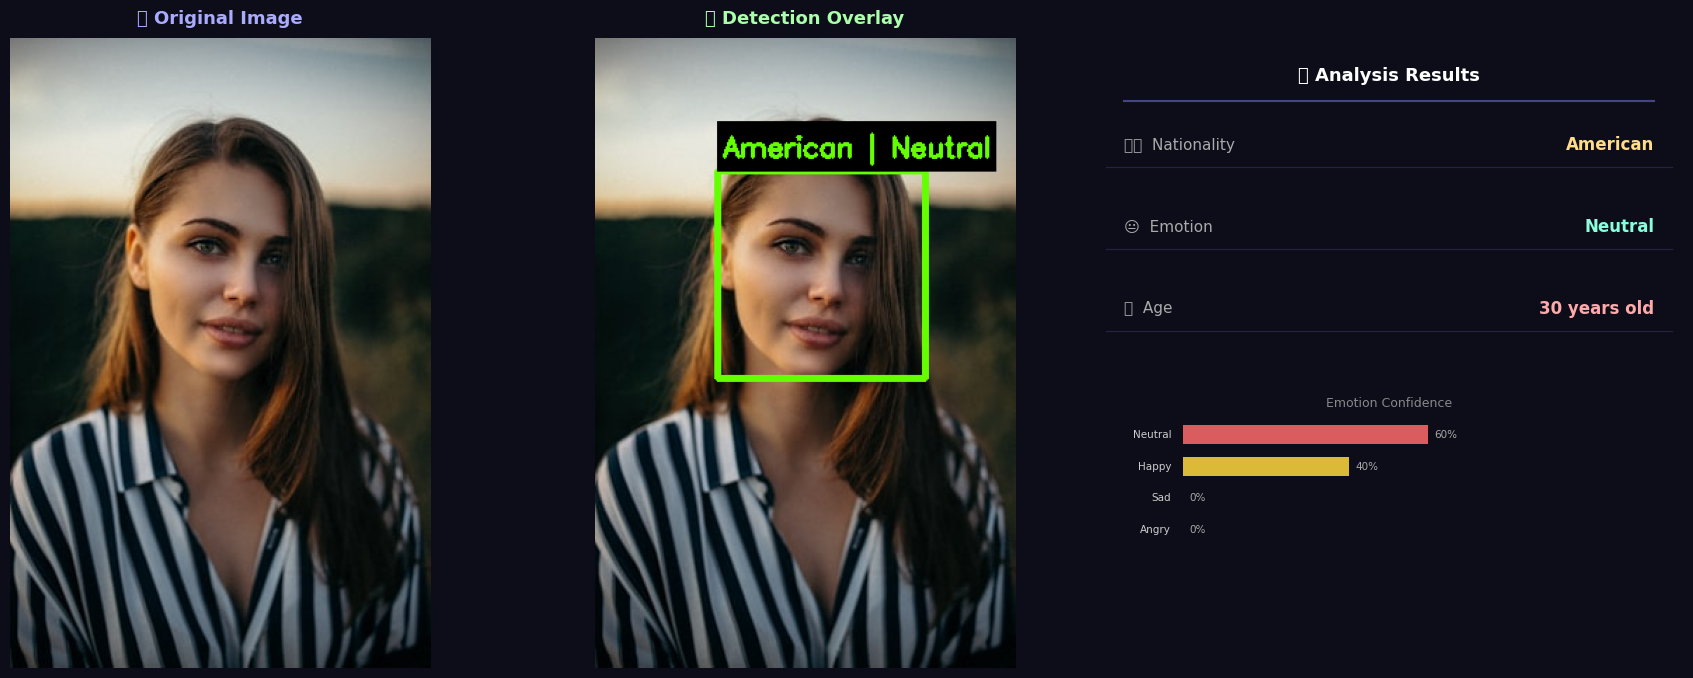


📥 Result saved as: /content/nationality_result.jpg


In [11]:
# Download a free sample face image for testing
import urllib.request
import os

# This is a free-to-use public domain face image
sample_url  = 'https://images.unsplash.com/photo-1544005313-94ddf0286df2?ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D&auto=format&fit=crop&w=300&h=450&q=80'
sample_path = '/content/test_face.jpg'

# Try to download a proper sample image
try:
    urllib.request.urlretrieve(sample_url, sample_path)
    print("✅ Sample image downloaded")
except Exception as e:
    print(f"ℹ️  Could not download sample: {e} — please use the Upload button in Cell 7")
    print("   Upload any clear face photo (JPG or PNG)")

# Or: just point to your own image path
# sample_path = '/content/your_image.jpg'

if os.path.exists(sample_path):
    print("\n🔍 Running analysis on sample image...\n")
    results = analyse_person(sample_path)
    display_results(sample_path, results)